In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('sales.csv')

df.head()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [27]:
#Count / Count distinct
print("Count / Count distinct:")
for col in df.columns:
    print(f"  {col}: count = {df[col].count()}, уникальных = {df[col].nunique()}")

Count / Count distinct:
  sale_id: count = 1000, уникальных = 1000
  branch: count = 1000, уникальных = 2
  city: count = 1000, уникальных = 3
  customer_type: count = 1000, уникальных = 2
  gender: count = 1000, уникальных = 2
  product_name: count = 1000, уникальных = 5
  product_category: count = 1000, уникальных = 5
  unit_price: count = 1000, уникальных = 787
  quantity: count = 1000, уникальных = 20
  tax: count = 1000, уникальных = 755
  total_price: count = 1000, уникальных = 956
  reward_points: count = 1000, уникальных = 43


In [28]:
#Count null / not null
print("Count null / not null:")
for col in df.columns:
    print(f"  {col}: пустых = {df[col].isnull().sum()}, непустых = {df[col].notnull().sum()}")


Count null / not null:
  sale_id: пустых = 0, непустых = 1000
  branch: пустых = 0, непустых = 1000
  city: пустых = 0, непустых = 1000
  customer_type: пустых = 0, непустых = 1000
  gender: пустых = 0, непустых = 1000
  product_name: пустых = 0, непустых = 1000
  product_category: пустых = 0, непустых = 1000
  unit_price: пустых = 0, непустых = 1000
  quantity: пустых = 0, непустых = 1000
  tax: пустых = 0, непустых = 1000
  total_price: пустых = 0, непустых = 1000
  reward_points: пустых = 0, непустых = 1000


In [29]:
#Length Max/Min/Avg
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    lengths = df[col].str.len()
    print(f"  {col}: min = {lengths.min()}, max = {lengths.max()}, avg = {round(lengths.mean(), 2)}")

  branch: min = 1, max = 1, avg = 1.0
  city: min = 7, max = 11, avg = 8.65
  customer_type: min = 6, max = 6, avg = 6.0
  gender: min = 4, max = 6, avg = 4.94
  product_name: min = 5, max = 12, avg = 8.24
  product_category: min = 6, max = 13, avg = 9.4


In [30]:
#Max/Min/Avg/Median/Mean/Percentile
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    print(f"  {col}:")
    print(f"    min = {df[col].min()}, max = {df[col].max()}")
    print(f"    mean = {round(df[col].mean(), 2)}, median = {df[col].median()}")
    print(f"    p25 = {df[col].quantile(0.25)}, p75 = {df[col].quantile(0.75)}, p95 = {df[col].quantile(0.95)}")

  sale_id:
    min = 1, max = 1000
    mean = 500.5, median = 500.5
    p25 = 250.75, p75 = 750.25, p95 = 950.05
  unit_price:
    min = 1.02, max = 20.98
    mean = 10.84, median = 10.614999999999998
    p25 = 5.8675, p75 = 15.8825, p95 = 19.9615
  quantity:
    min = 1, max = 20
    mean = 10.34, median = 10.0
    p25 = 5.0, p75 = 16.0, p95 = 20.0
  tax:
    min = 0.08, max = 28.39
    mean = 7.76, median = 5.87
    p25 = 2.51, p75 = 11.522499999999999, p95 = 20.935499999999994
  total_price:
    min = 1.21, max = 433.99
    mean = 118.58, median = 89.705
    p25 = 38.38, p75 = 176.0725, p95 = 320.07249999999993
  reward_points:
    min = 0, max = 43
    mean = 6.06, median = 0.0
    p25 = 0.0, p75 = 10.0, p95 = 28.0


In [31]:
#PSI (population stability index)
def calculate_psi(expected, actual, buckets=10):
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    expected_perc = np.histogram(expected, breakpoints)[0] / len(expected)
    actual_perc = np.histogram(actual, breakpoints)[0] / len(actual)

    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)

    return ((expected_perc - actual_perc) * np.log(expected_perc / actual_perc)).sum()

half = len(df) // 2
df_first = df.iloc[:half]
df_second = df.iloc[half:]

print("PSI:")
for col in num_cols:
    psi = calculate_psi(df_first[col].values, df_second[col].values)
    print(f"  {col}: PSI = {round(psi, 4)}")

PSI:
  sale_id: PSI = 8.2831
  unit_price: PSI = 0.0182
  quantity: PSI = 0.0526
  tax: PSI = 0.017
  total_price: PSI = 0.0154
  reward_points: PSI = 0.0036


In [32]:
#Stddev
for col in num_cols:
    print(f"  {col}: std = {round(df[col].std(), 2)}")

  sale_id: std = 288.82
  unit_price: std = 5.78
  quantity: std = 6.03
  tax: std = 6.54
  total_price: std = 99.94
  reward_points: std = 9.35


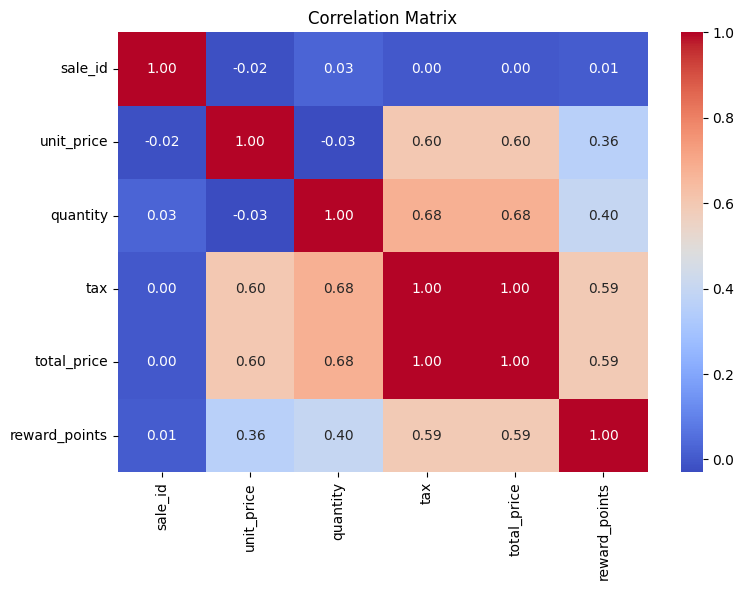

               sale_id  unit_price  quantity   tax  total_price  reward_points
sale_id           1.00       -0.02      0.03  0.00         0.00           0.01
unit_price       -0.02        1.00     -0.03  0.60         0.60           0.36
quantity          0.03       -0.03      1.00  0.68         0.68           0.40
tax               0.00        0.60      0.68  1.00         1.00           0.59
total_price       0.00        0.60      0.68  1.00         1.00           0.59
reward_points     0.01        0.36      0.40  0.59         0.59           1.00


In [33]:
#Corr Matrix
corr = df[num_cols].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print(corr)

In [34]:
#topX values
for col in cat_cols:
    print(f"\n  {col}:")
    print(df[col].value_counts().head())


  branch:
branch
A    674
B    326
Name: count, dtype: int64

  city:
city
New York       344
Chicago        330
Los Angeles    326
Name: count, dtype: int64

  customer_type:
customer_type
Member    516
Normal    484
Name: count, dtype: int64

  gender:
gender
Male      528
Female    472
Name: count, dtype: int64

  product_name:
product_name
Shampoo         224
Orange Juice    208
Notebook        194
Detergent       189
Apple           185
Name: count, dtype: int64

  product_category:
product_category
Fruits           209
Personal Care    208
Stationery       198
Household        198
Beverages        187
Name: count, dtype: int64


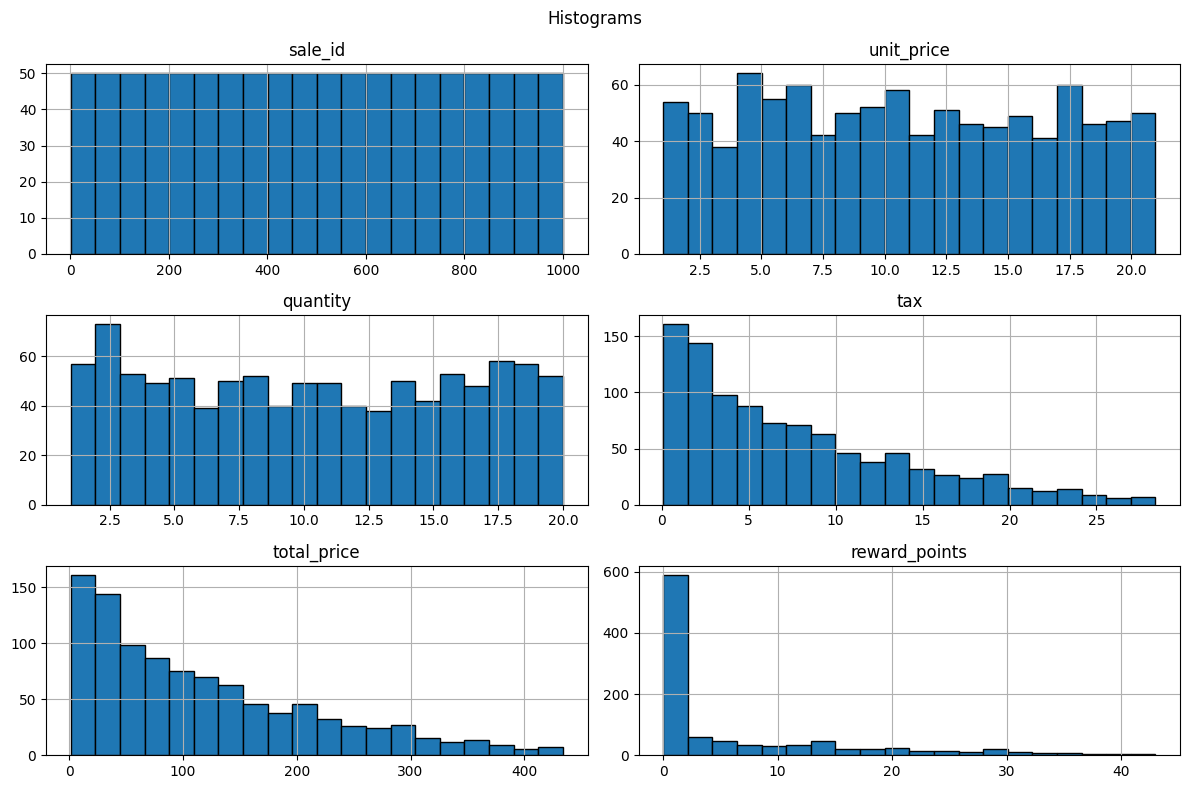

In [35]:
#Histogram
df[num_cols].hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle('Histograms')
plt.tight_layout()
plt.show()